<a href="https://colab.research.google.com/github/raphasandes/Auditoria-Vendas-e-Lucratividade/blob/main/RID220190_Desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio 01 - Análise de métricas RFV com Clustering

## Objetivo
Construir modelo de clusterização para agrupar clientes de um e-commerce com base nas métricas RFV.

- **Recency (Recência)**: há quantos dias o cliente fez a compra mais recente;
- **Frequency (Frequência)**: quantas compras o cliente realizou;
- **Monetary (Valor Monetário)**: quanto o cliente gastou no total.

Ao final, o objetivo é interpretar os clusters e propor ações de negócio para a empresa.

## Etapa Inicial - Importação das bibliotecas necessárias

In [28]:
#Lista de bibliotecas selecionadas com ajuda de IA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Etapa 1 - Carregamento da base



In [29]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data (1).csv


In [30]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## Etapa 2 - Análise exploratória inicial

Objetivos:
- verificar dimensões da base;
- identificar tipos de dados;
- analisar estatísticas descritivas;
- procurar dados nulos e duplicados.

In [31]:
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')
print('\nTipos de dados:')
print(df.dtypes)

Linhas: 541909
Colunas: 8

Tipos de dados:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


In [33]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,218.08,"-80,995.00",1.00,3.00,10.00,"80,995.00"
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,96.76,"-11,062.06",1.25,2.08,4.13,"38,970.00"
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","1,713.60","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
print('Valores nulos por coluna:')
display(df.isnull().sum())

print('\nQuantidade de linhas duplicadas:', df.duplicated().sum())

Valores nulos por coluna:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Quantidade de linhas duplicadas: 5268


## Etapa 3 - Ajustes iniciais e limpeza

Tratar:
- `CustomerID` nulo;
- quantidades negativas ou iguais a zero;
- preços negativos ou iguais a zero;
- duplicidades;
- conversão correta da data.

In [35]:
# Cópia para preservar a base original
df_clean = df.copy()

# Conversão de data
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Remoção de duplicatas
df_clean = df_clean.drop_duplicates()

# Remoção de linhas sem identificação do cliente
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remoção de quantidades e preços inválidos
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Ajuste de tipo do CustomerID
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print('Base após limpeza:', df_clean.shape)
df_clean.head()

Base após limpeza: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [36]:
print('Valores nulos restantes:')
display(df_clean.isnull().sum())

print('\nResumo estatístico após limpeza:')
display(df_clean.describe())

Valores nulos restantes:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0



Resumo estatístico após limpeza:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"392,692.00",392692,"392,692.00","392,692.00"
mean,13.12,2011-07-10 19:13:07.771892480,3.13,"15,287.84"
min,1.00,2010-12-01 08:26:00,0.00,"12,346.00"
25%,2.00,2011-04-07 11:12:00,1.25,"13,955.00"
50%,6.00,2011-07-31 12:02:00,1.95,"15,150.00"
75%,12.00,2011-10-20 12:53:00,3.75,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"8,142.75","18,287.00"
std,180.49,NaN,22.24,"1,713.54"


## Etapa 4 - Criação da variável de valor total da compra

A métrica monetária será construída a partir da multiplicação:

**Valor total = Quantidade × Preço unitário**

In [37]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Etapa 5 - Construção da tabela RFV


- **Recency**: diferença, em dias, entre a data de referência e a última compra do cliente;
- **Frequency**: número de faturas únicas (`InvoiceNo`);
- **Monetary**: soma do valor total gasto pelo cliente.

In [38]:
# Data de referência: 1 dia após a compra mais recente da base
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Data de referência:', reference_date)

Data de referência: 2011-12-10 12:50:00


In [39]:
rfv = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfv.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


In [40]:
rfv.describe()

,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,048.69"
std,"1,721.81",100.01,7.70,"8,985.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,306.48
50%,"15,299.50",51.00,2.00,668.57
75%,"16,778.75",142.00,5.00,"1,660.60"
max,"18,287.00",374.00,209.00,"280,206.02"


## Etapa 6 - Visualização das distribuições



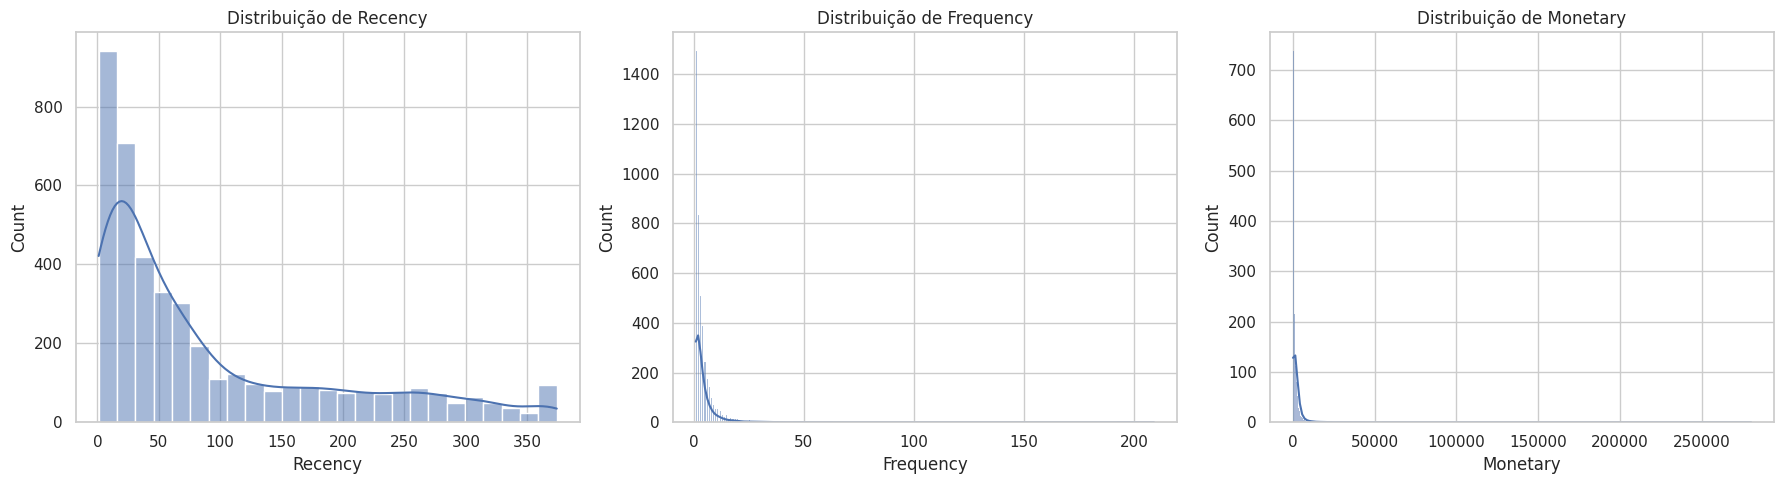

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfv['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Recency')

sns.histplot(rfv['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Frequency')

sns.histplot(rfv['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Monetary')

plt.tight_layout()
plt.show()

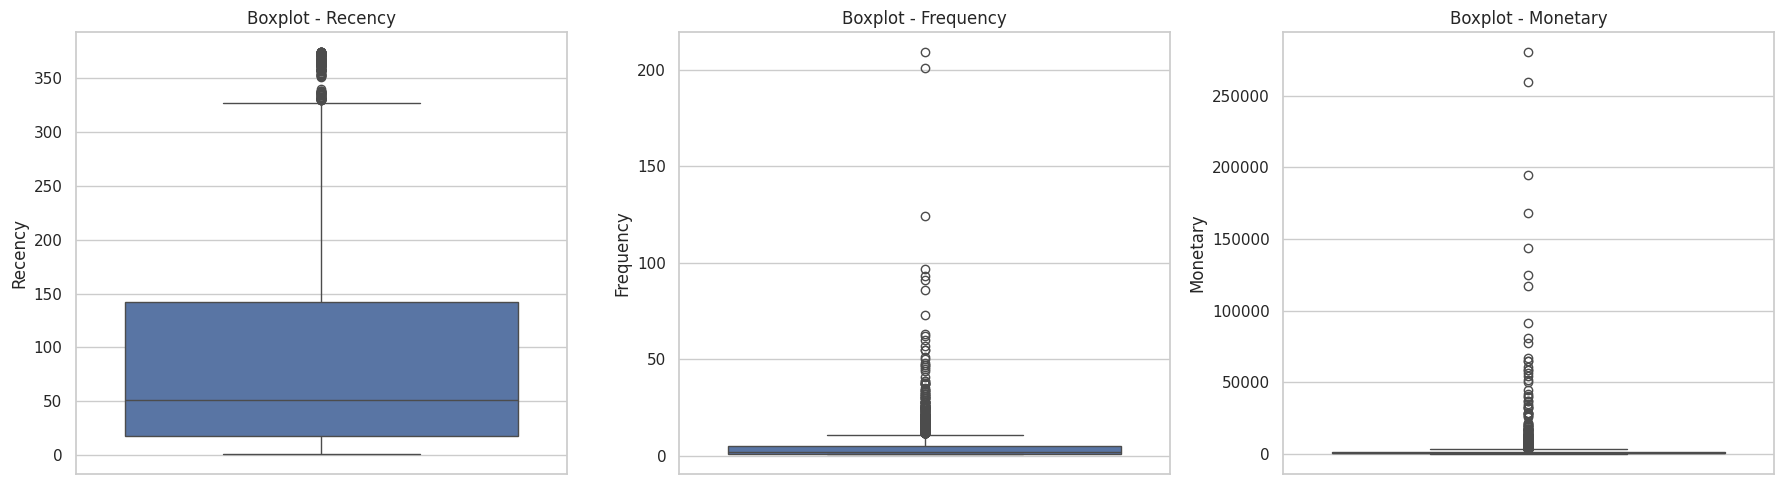

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfv['Recency'], ax=axes[0])
axes[0].set_title('Boxplot - Recency')

sns.boxplot(y=rfv['Frequency'], ax=axes[1])
axes[1].set_title('Boxplot - Frequency')

sns.boxplot(y=rfv['Monetary'], ax=axes[2])
axes[2].set_title('Boxplot - Monetary')

plt.tight_layout()
plt.show()

## Etapa 7 - Transformação logarítmica

Como `Frequency` e `Monetary` costumam ter caudas longas, aplicamos `log1p` para reduzir a assimetria e melhorar a clusterização.

In [43]:
rfv_model = rfv[['Recency', 'Frequency', 'Monetary']].copy()
rfv_log = np.log1p(rfv_model)

rfv_log.describe()

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,3.83,1.35,6.59
std,1.34,0.68,1.26
min,0.69,0.69,1.56
25%,2.94,0.69,5.73
50%,3.95,1.10,6.51
75%,4.96,1.79,7.42
max,5.93,5.35,12.54


## Etapa 8 - Padronização dos dados

O KMeans é sensível à escala das variáveis.  
Por isso, usamos o `StandardScaler` para deixar todas na mesma escala.

In [44]:
scaler = StandardScaler()
rfv_scaled = scaler.fit_transform(rfv_log)

rfv_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

## Etapa 9 - Escolha do número de clusters

Usaremos:
- Método do cotovelo (Elbow);
- Silhouette Score.

> Observação: para deixar o notebook mais leve, o silhouette será calculado com amostragem.

In [45]:
inertia = []
silhouette_scores = []
K = range(2, 9)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfv_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfv_scaled, labels, sample_size=min(1000, len(rfv_scaled)), random_state=42)
    )

results_k = pd.DataFrame({
    'k': list(K),
    'inertia': inertia,
    'silhouette_score': silhouette_scores
})

results_k

,k,inertia,silhouette_score
0,2,"6,483.59",0.43
1,3,"4,869.49",0.33
2,4,"3,939.05",0.34
3,5,"3,296.71",0.32
4,6,"2,855.76",0.32
5,7,"2,548.82",0.31
6,8,"2,336.34",0.30


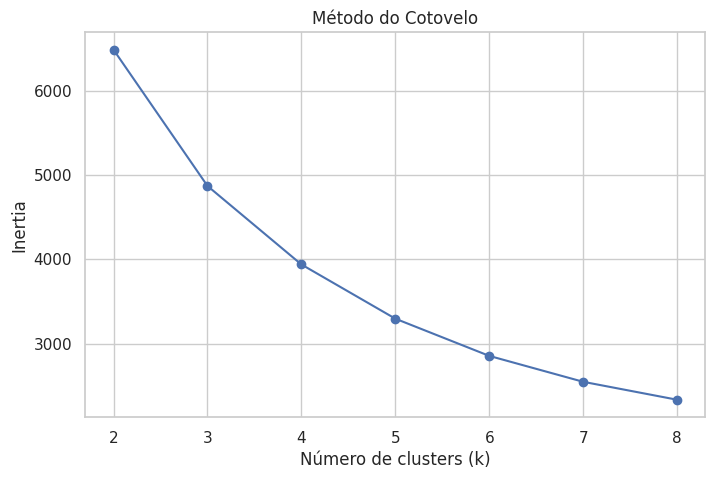

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(results_k['k'], results_k['inertia'], marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.show()

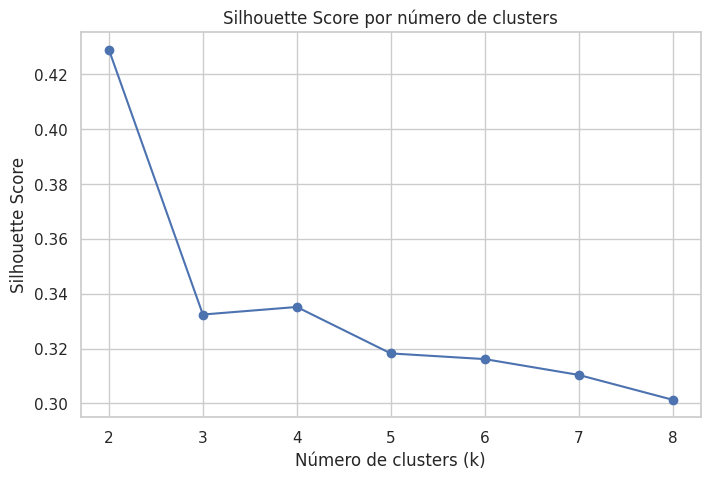

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(results_k['k'], results_k['silhouette_score'], marker='o')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

## Etapa 10 - Definição do modelo final

Neste notebook, vamos seguir com **k = 4**, porque costuma oferecer boa separação e interpretação de perfis em problemas RFV.

In [48]:
k_final = 4

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfv['Cluster'] = kmeans_final.fit_predict(rfv_scaled)

rfv.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,"77,183.60",3
1,12347,2,7,"4,310.00",0
2,12348,75,4,"1,797.24",3
3,12349,19,1,"1,757.55",2
4,12350,310,1,334.40,1


## Etapa 11 - Análise descritiva dos clusters

In [49]:
cluster_summary = rfv.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_summary['Clientes'] = rfv['Cluster'].value_counts().sort_index()
cluster_summary['Percentual'] = (cluster_summary['Clientes'] / len(rfv) * 100).round(2)

cluster_summary

,Recency,Frequency,Monetary,Clientes,Percentual
Cluster,,,,,
0,12.17,13.75,"8,088.02",713,16.44
1,181.51,1.32,341.00,1622,37.39
2,17.70,2.19,557.32,837,19.29
3,71.64,4.08,"1,801.78",1166,26.88


In [50]:
rfv.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,8.00,10.00,"3,722.82"
1,174.50,1.00,296.09
2,17.00,2.00,480.31
3,57.00,4.00,"1,345.20"


## Interpretação dos Clusters

A análise dos clusters foi realizada com base nas médias das variáveis Recency, Frequency e Monetary.

Observa-se que os grupos apresentam comportamentos distintos de compra, permitindo segmentar os clientes de forma estratégica.


#### Cluster 0
Apresenta baixa recência, alta frequência e alto valor monetário.  
São clientes que compram com frequência, gastam mais e realizaram compras recentemente.

Perfil: Clientes VIP / altamente engajados  
Comportamento: Alta fidelidade e alto valor para o negócio  

__
####Cluster 1
Apresenta alta recência, baixa frequência e baixo valor monetário.  
Não compram há bastante tempo e possuem baixo nível de interação com a empresa.

Perfil: Clientes inativos ou em risco de churn  
Comportamento: Baixo engajamento e alta probabilidade de abandono  

__
#### Cluster 2
Clientes com frequência intermediária e valor monetário moderado.  
Apesar de não serem os maiores compradores, apresentam consistência nas compras.

Perfil: Clientes regulares  
Comportamento: Estáveis, com potencial de crescimento  

__
#### Cluster 3
Baixa frequência, porém recência relativamente baixa.  
Podem ser clientes novos ou ocasionais.

Perfil: Clientes novos ou ocasionais  
Comportamento: Ainda em fase de desenvolvimento de relacionamento com a empresa  

## Etapa 12 - Visualização dos clusters com PCA

Como temos 3 dimensões, podemos reduzi-las para 2 componentes principais apenas para fins de visualização.

In [51]:
pca = PCA(n_components=2, random_state=42)
rfv_pca = pca.fit_transform(rfv_scaled)

rfv['PCA1'] = rfv_pca[:, 0]
rfv['PCA2'] = rfv_pca[:, 1]

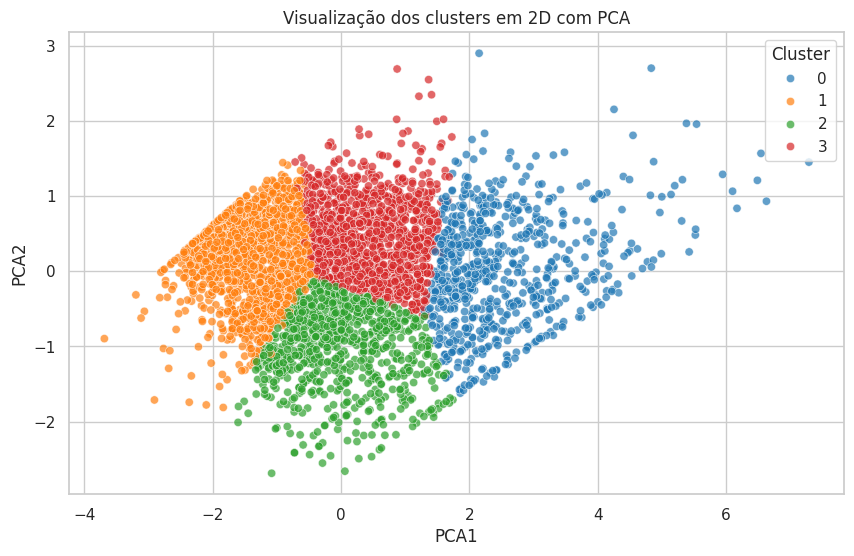

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfv, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title('Visualização dos clusters em 2D com PCA')
plt.show()

## Etapa 13 - Distribuição das métricas por cluster

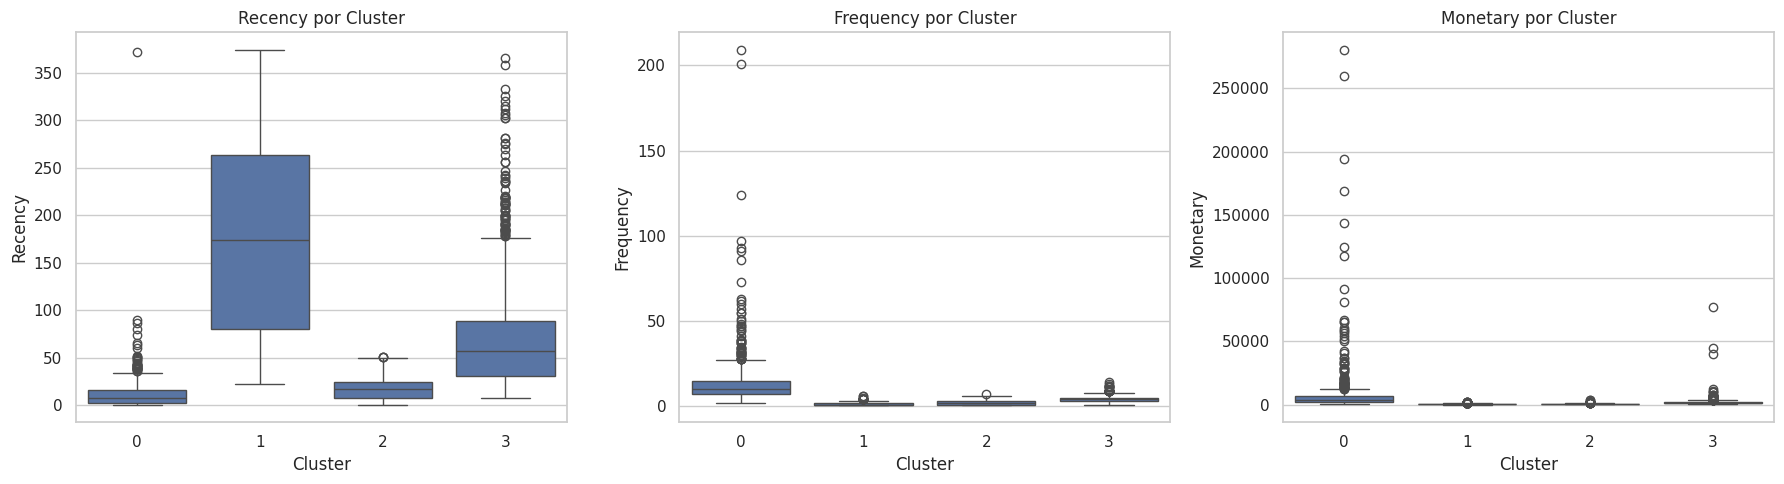

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=rfv, x='Cluster', y='Recency', ax=axes[0])
axes[0].set_title('Recency por Cluster')

sns.boxplot(data=rfv, x='Cluster', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency por Cluster')

sns.boxplot(data=rfv, x='Cluster', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary por Cluster')

plt.tight_layout()
plt.show()

## Etapa 14 - Ranking dos clusters


In [54]:
ranking = cluster_summary.copy()

ranking['Rank_Recency'] = ranking['Recency'].rank(ascending=True, method='dense')
ranking['Rank_Frequency'] = ranking['Frequency'].rank(ascending=False, method='dense')
ranking['Rank_Monetary'] = ranking['Monetary'].rank(ascending=False, method='dense')

ranking['Score_Total'] = ranking[['Rank_Recency', 'Rank_Frequency', 'Rank_Monetary']].sum(axis=1)
ranking.sort_values('Score_Total')

,Recency,Frequency,Monetary,Clientes,Percentual,Rank_Recency,Rank_Frequency,Rank_Monetary,Score_Total
Cluster,,,,,,,,,
0,12.17,13.75,"8,088.02",713,16.44,1.00,1.00,1.00,3.00
3,71.64,4.08,"1,801.78",1166,26.88,3.00,2.00,2.00,7.00
2,17.70,2.19,557.32,837,19.29,2.00,3.00,3.00,8.00
1,181.51,1.32,341.00,1622,37.39,4.00,4.00,4.00,12.00


## Etapa 15 - Interpretação dos clusters

- **Cluster com baixa recência, alta frequência e alto valor monetário**  
  Perfil: clientes VIP / muito engajados.

- **Cluster com alta recência, baixa frequência e baixo valor monetário**  
  Perfil: clientes inativos ou em risco de churn.

- **Cluster com baixa frequência, mas recência razoável**  
  Perfil: clientes ocasionais ou novos.

- **Cluster com frequência média e ticket médio intermediário**  
  Perfil: clientes regulares com potencial de crescimento.

## Etapa 16 - Sugestões de ações de negócio

As recomendações abaixo podem ser adaptadas conforme os resultados observados:

### 1. Clientes VIP
- campanhas de fidelização;
- benefícios exclusivos;
- cupons e recompensas por recorrência;
- ofertas de produtos premium.

### 2. Clientes regulares
- cross-sell e upsell;
- combos e recomendações personalizadas;
- campanhas para elevar o ticket médio.

### 3. Clientes ocasionais / novos
- ações de onboarding;
- incentivo para segunda compra;
- cupons de boas-vindas ou frete grátis.

### 4. Clientes inativos / em risco
- campanhas de reativação;
- ofertas personalizadas;
- comunicação com senso de urgência;
- resgate com desconto.

17 - Conclusão

Neste trabalho, foi desenvolvido um modelo de clusterização utilizando as métricas RFV (Recência, Frequência e Valor Monetário) para segmentar clientes de um e-commerce.

A aplicação do algoritmo KMeans permitiu identificar diferentes perfis de clientes com base em seus comportamentos de compra, possibilitando uma análise mais estratégica da base de clientes.

Os resultados demonstram que a segmentação baseada em dados é uma ferramenta poderosa para apoiar decisões de negócio, especialmente na personalização de campanhas de marketing, retenção de clientes e aumento de receita.

Dessa forma, o uso de técnicas de clusterização contribui diretamente para a geração de valor para a empresa, transformando dados em insights acionáveis.